In [2]:
import os
import numpy as np
import scipy
from scipy.io import wavfile
import scipy.fftpack as fft # buat FFT
from scipy.signal import get_window # Window Func
from IPython.display import Audio, display
import matplotlib.pyplot as plt

In [3]:
SAMPLE_AUDIO_PATH = "dataset/sample.wav"
display(Audio(SAMPLE_AUDIO_PATH, rate=16000))


In [4]:
# Load Audio
sample_rate, audio = wavfile.read(SAMPLE_AUDIO_PATH)
audio_duration = len(audio) / sample_rate

# cut to 15 seconds
if audio_duration > 15:
    audio = audio[:15 * sample_rate]
    audio_duration = 15

print(f"Sample Rate: {sample_rate} Hz")
print(f"Audio Duration: {audio_duration:.2f} seconds")

Sample Rate: 16000 Hz
Audio Duration: 15.00 seconds


In [5]:
# Normalizaiton

audio = audio / np.max(np.abs(audio))  # Normalize audio to [-1, 1]

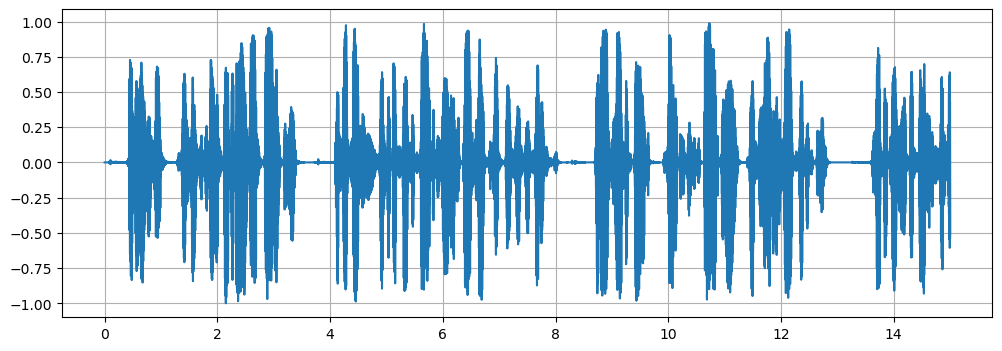

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, audio_duration, num=len(audio)), audio)
plt.grid(True)

In [7]:
# Framing
# memecah audio menjadi segmen2 kecil yang overlap

def frame_audio(audio, FFT_size, hop_size, sample_rate):
    # Audio: Signal size kita
    # FFT_size: jumlah sample disuatu fram
    # hop_size: jumlah sample yang di skip untuk frame berikutnya
    # sample_rate: sample rate dari audio
    
    # Padding: nambah di awal dan akhir audio supaya framingnya pas
    # [1,2,3,4,5] -> [3,2,1,2,3,4,5,4,3] (contoh)
    audio = np.pad(audio, int(FFT_size/2), mode='reflect')
    
    # ubah dari hop_size menjadi hop_length
    hop_len = np.round(sample_rate * (hop_size / 1000)).astype(int)
    
    # hitung jumlah frame
    frame_num = int((len(audio) - FFT_size) / hop_len) + 1
    
    # Inisialisasi amtriks kosong untuk simpan hasil framing
    frames = np.zeros((frame_num, FFT_size))
    
    # Looping untuk isi matriks frame
    # Tiap iterasi, ambil potongan audio sebesar FFT_size
    for i in range(frame_num):
        frames[i] = audio[i * hop_len : i * hop_len + FFT_size]
        
    return frames

In [8]:
hop_size = 15  # in milliseconds
FFT_size = 2048  # in samples
audio_framed = frame_audio(audio, FFT_size, hop_size, sample_rate)
audio_framed.shape  # (frame_num, FFT_size)

(1001, 2048)

In [9]:
# Windowing: membuat ujung awal dan akhir dekat / sampai 0
# Tujuannya mengurangi spectral leakage saat FFT

window = get_window('hann', FFT_size, fftbins=True)

audio_win = audio_framed * window
audio_winT = np.transpose(audio_win)  # transpose supaya bisa di FFT
audio_winT.shape  # (FFT_size, frame_num)

(2048, 1001)

Text(0, 0.5, 'Amplitude')

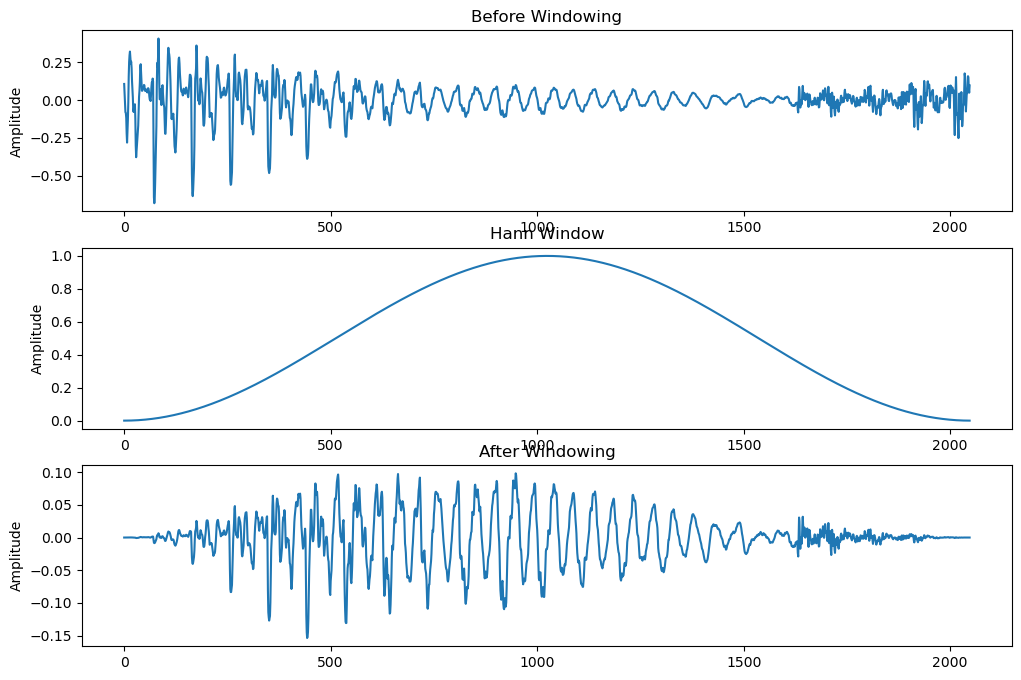

In [10]:
frame_idx = 110

frame_before = audio_framed[frame_idx]
frame_after = audio_win[frame_idx]

# match axis x sesuai sama panjang frame
samples = np.arange(len(frame_before))

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Before Windowing
axes[0].plot(samples, frame_before)
axes[0].set_title("Before Windowing")
axes[0].set_ylabel("Amplitude")

# Hann Window
axes[1].plot(samples, window)
axes[1].set_title("Hann Window")
axes[1].set_ylabel("Amplitude")

# After Windowing
axes[2].plot(samples, frame_after)
axes[2].set_title("After Windowing")
axes[2].set_ylabel("Amplitude")

In [11]:
# FFT: convert time domain ke frequency domain

# input audio bernilai dari bilangan rill, jadi FFT simetris
audio_fft = np.empty((int(1 + FFT_size // 2), audio_winT.shape[1]), dtype=np.complex64, order='F') # inisialisasi array kosong untuk simpan hasil FFT

for i in range(audio_fft.shape[1]):
    audio_fft[:, i] = fft.fft(audio_winT[:, i], axis=0)[:audio_fft.shape[0]]
    
audio_fft = np.transpose(audio_fft)  # transpose supaya bisa di plot
audio_fft.shape  # (frame_num, FFT_size/2+1)

print(audio_fft[:3, :5])  # print 3 frame pertama, 5 frekuensi pertama

[[ 0.0000000e+00-0.0000000e+00j  0.0000000e+00+0.0000000e+00j
   0.0000000e+00-0.0000000e+00j  0.0000000e+00+0.0000000e+00j
   0.0000000e+00+0.0000000e+00j]
 [-2.6664366e-05-0.0000000e+00j -3.2461361e-05+4.5014335e-06j
  -4.5709254e-05-8.0670873e-07j -5.6174998e-05-2.0024787e-05j
  -5.3024898e-05-4.8752572e-05j]
 [-1.1375252e-03-0.0000000e+00j -7.9884951e-04-7.9587800e-04j
   3.0647814e-05-1.0903946e-03j  7.9461973e-04-6.3020957e-04j
   8.6146430e-04+2.4617129e-04j]]


In [12]:
# Audio Power: spektrum daya audio
# Menghitung kuadrat dari amplitudo FFT

# Habis FFT, outputnya bilangan complex, jadi kita ambil magnitudo lalu dikuadrat

audio_power = np.square(np.abs(audio_fft))
audio_power.shape  # (frame_num, FFT_size/2+1)

(1001, 1025)

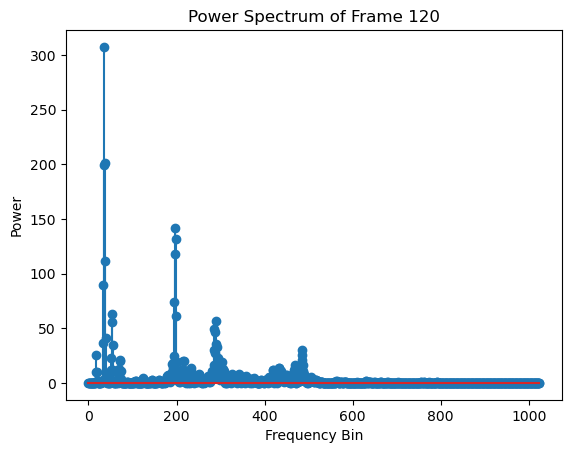

In [13]:
frame = 120

plt.stem(audio_power[frame])

plt.xlabel("Frequency Bin")
plt.ylabel("Power")
plt.title(f"Power Spectrum of Frame {frame}")
plt.show()

In [16]:
# Mel Filterbank
fmin = 0
fmax = sample_rate / 2
mel_filter_num = 10

In [14]:
# bikin rumus konversi Mel -> Freq / Freq -> Mel
def freq_to_mel(freq):
    return 2595 * np.log10(1 + freq / 700)

def mel_to_freq(mel):
    return 700 * (10**(mel / 2595) - 1)

In [18]:
def get_filter_points(fmin, fmax, mel_filter_num, FFT_size, sample_rate):
    # fmin: frekuensi minimum
    # fmax: frekuensi maksimum
    # mel_filter_num: jumlah filter mel
    # FFT_size: ukuran FFT
    # sample_rate: sample rate dari audio
    
    # konversi frekuensi ke mel
    mel_min = freq_to_mel(fmin)
    mel_max = freq_to_mel(fmax)
    
    # buat array mel yang terdistribusi secara linear
    mel_points = np.linspace(mel_min, mel_max, mel_filter_num + 2)
    
    # konversi kembali ke frekuensi
    freq_points = mel_to_freq(mel_points)
    
    return ((FFT_size + 1) / sample_rate * freq_points).astype(int), freq_points

In [17]:
filter_points, mel_freqs = get_filter_points(fmin, fmax, mel_filter_num, FFT_size, sample_rate)
print(filter_points)
print(mel_freqs)

[   0   23   52   88  134  192  264  355  470  614  796 1024]
[   0.          180.21928115  406.83711843  691.7991039  1050.12629534
 1500.70701371 2067.29249375 2779.74887082 3675.63149949 4802.16459006
 6218.73051459 8000.        ]


In [29]:
def get_filter(filter_points, FFT_size):
    filters = np.zeros((len(filter_points) - 2, int(FFT_size / 2 + 1)))
    
    for i in range(len(filter_points) - 2):
        filters[i, filter_points[i]:filter_points[i + 1]] = np.linspace(0, 1, filter_points[i + 1] - filter_points[i])
        filters[i, filter_points[i + 1]:filter_points[i + 2]] = np.linspace(1, 0, filter_points[i + 2] - filter_points[i + 1])
        
    return filters

In [30]:
filters = get_filter(filter_points, FFT_size)
filters.shape  # (mel_filter_num, FFT_size/2+1)

(10, 1025)

In [31]:
# Normalization
enorm = 2.0 / (mel_freqs[2:mel_filter_num + 2] - mel_freqs[:mel_filter_num])
enorm.shape  # (mel_filter_num,)

(10,)

In [32]:
enorm = enorm[:, np.newaxis]  # reshape to (mel_filter_num, 1) for broadcasting
enorm.shape  # (mel_filter_num, 1)

(10, 1)

In [33]:
filters = filters * enorm  # apply normalization
filters.shape  # (mel_filter_num, FFT_size/2+1)

(10, 1025)

In [34]:
# Filter audio
audio_filtered = np.dot(filters, np.transpose(audio_power))  # apply mel filterbank to power spectrum
audio_filtered.shape  # (mel_filter_num, frame_num)

audio_log = 10.0 * np.log10(audio_filtered)
audio_log.shape  # (mel_filter_num, frame_num)

/var/folders/lr/rkt0d17524s_jcwydyd8zzdr0000gn/T/ipykernel_38211/569860983.py:5: RuntimeWarning: divide by zero encountered in log10
  audio_log = 10.0 * np.log10(audio_filtered)


(10, 1001)

In [35]:
# DCT (Discrete cosine transpose) <- full rumus
# FFT domain filtered -> koefisien yang bisa efficient untuk speech processing

def dct(dct_filter_num, filter_len):
    basis = np.empty((dct_filter_num, filter_len))
    
    basis[0, :] = 1.0 / np.sqrt(filter_len)
    
    samples = np.arange(1, 2 * filter_len, 2) * np.pi / (2.0 * filter_len)
    
    for i in range(1, dct_filter_num):
        basis[i, :] = np.cos(i * samples) * np.sqrt(2.0 / filter_len)
        
    return basis

In [36]:
dct_filter_num = 40
dct_filter = dct(dct_filter_num, mel_filter_num)
dct_filter.shape  # (dct_filter_num, mel_filter_num)

(40, 10)

In [37]:
# Coefficient Cepstral

cc = np.dot(dct_filter, audio_log)
cc.shape
    

(40, 1001)

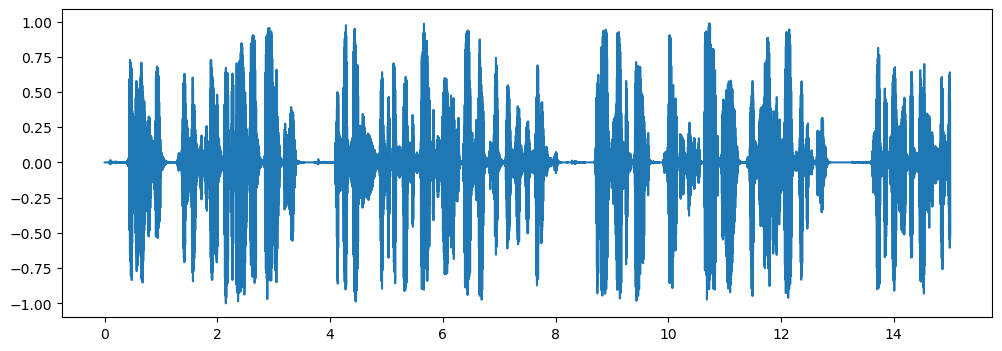

In [38]:
plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, len(audio) / sample_rate, num=len(audio)), audio)

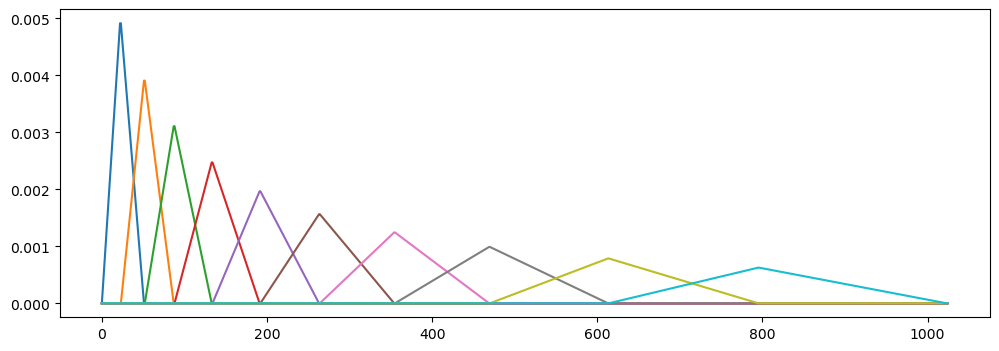

In [39]:
plt.figure(figsize=(12, 4))
for i in range(filters.shape[0]):
    plt.plot(filters[i])